<a href="https://colab.research.google.com/github/nuralfiyanti/ML_Ganjil2026/blob/main/JS04_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Praktikum 1**


**Download dataset `Iris.csv` terlebih dahulu**

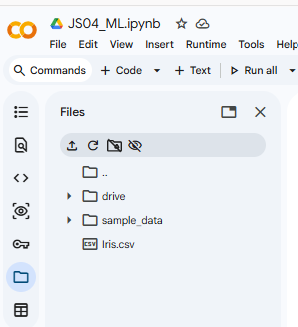

#### **KMeans**
KMeans adalah satu metode unsupervised learning pada machine learning. Metode ini menentukan jumlah cluster sesuai dengan jumlah
k
k yang dipilih. Proses KMeans secara manual, dapat dilihat pada tautan berikut,

#### Perhitungan Manual KMeans

Pada modul jobsheet ini, kita akan langsung mempraktikkan pembuatan model KMeans dengan menggunakan python. Untuk modul pertama ini, kita akan menggunakan contoh kasus yang sederhana, yaitu dengan menggunakan dataset iris. Sedangkan untuk modul kedua, kita akan melakukan clustering dengan lebih advance, yaitu reduksi warna dengan data gambar

In [1]:
# Persiapan data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv('Iris.csv')

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [2]:
# Seleksi Fitur

X = df.iloc[:, 1:-1]
y = df.iloc[:, -1]

X.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


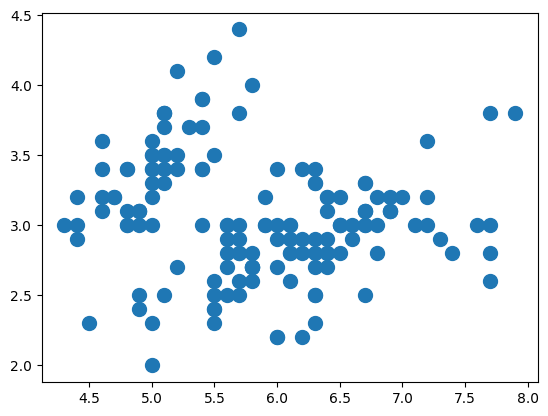

In [3]:
# Plot Data
# Karena data 4 dimensi, maka akan kita coba
# plot cluster berdasarkan Sepal Length dan Sepal Width  saja

plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100)


In [4]:
# Buat Model KMeans
# Kali ini kita coba menggunakan k=2 - anggap saja kita tidak tahu jumlah label ada 3 :)

from sklearn.cluster import KMeans

# Inisiasi obyek KMeans
cl_kmeans = KMeans(n_clusters=2)

# Fit dan predict model
y_kmeans = cl_kmeans.fit_predict(X)

Nanti akan muncul tampilan seperti dibawah ini



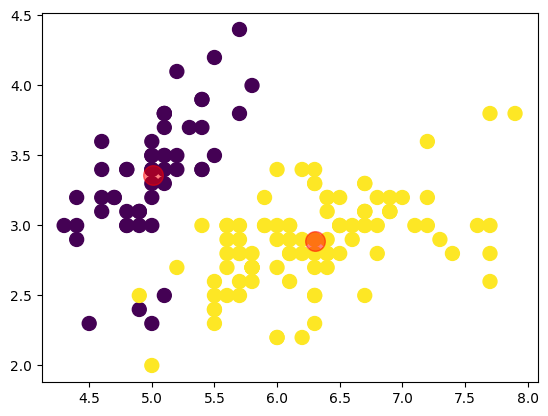

In [5]:
# Plot hasi cluster berdasarkan Sepal Length dan Sepal Width
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100, c=y_kmeans)

# Plot centroid
centers = cl_kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5)

In [6]:
# Cek Nilai SSE
print(f'Nilai SSE: {cl_kmeans.inertia_}')

Nilai SSE: 152.36870647733915


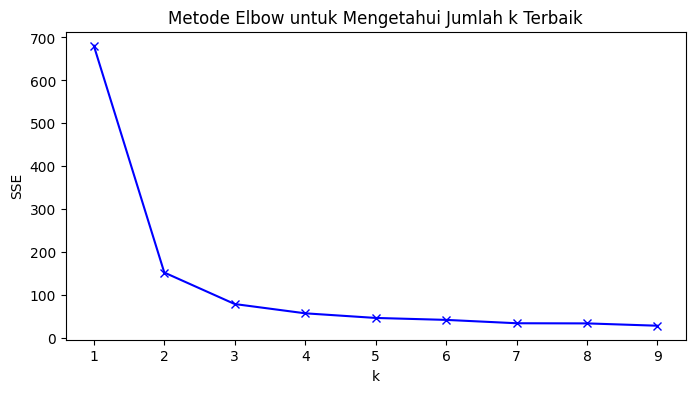

In [7]:
# Implementasi Metode Elbow

# List nilai SSE
sse = []

# Cari k terbaik dari 1-10
K = range(1,10)

# Cek nilai SSE setiap k
for k in K:
 kmeanModel = KMeans(n_clusters=k)
 kmeanModel.fit(X)
 sse.append(kmeanModel.inertia_)


# Plotting the distortions
plt.figure(figsize=(8,4))
plt.plot(K, sse, "bx-")
plt.xlabel("k")
plt.ylabel("SSE")
plt.title("Metode Elbow untuk Mengetahui Jumlah k Terbaik")
plt.show()


In [8]:
# Cek Nilai SSE setiap k
for idx, sse_val in enumerate(sse, start=1):
    print(f'k={idx}; SSE={sse_val}')

k=1; SSE=680.8243999999996
k=2; SSE=152.36870647733915
k=3; SSE=78.94084142614601
k=4; SSE=57.34540931571815
k=5; SSE=46.56163015873017
k=6; SSE=42.02656666666665
k=7; SSE=34.1967910993998
k=8; SSE=33.858759118096074
k=9; SSE=28.43740221051092


# **Praktikum 2**

import library




In [9]:
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np

#### **Pengantar k-Means**



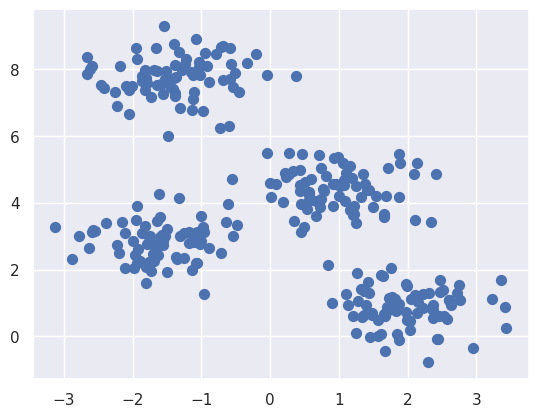

In [10]:
from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.60, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s=50);

In [11]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

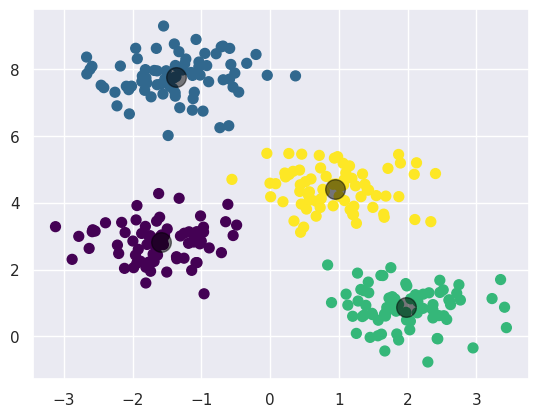

In [12]:
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)

#### **Algoritma Expectation-Maximization**



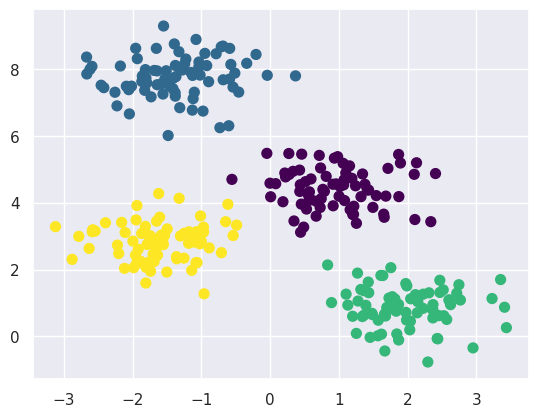

In [13]:
from sklearn.metrics import pairwise_distances_argmin

def find_clusters(X, n_clusters, rseed=2):
    # 1. Randomly choose clusters
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]

    while True:
        # 2a. input label center yang baru
        labels = pairwise_distances_argmin(X, centers)

        # 2b. update center dari titik baru
        new_centers = np.array([X[labels == i].mean(0)
                                for i in range(n_clusters)])

        # 2c. cek konvergensi
        if np.all(centers == new_centers):
            break
        centers = new_centers

    return centers, labels

centers, labels = find_clusters(X, 4)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

#### **Perubahan random**



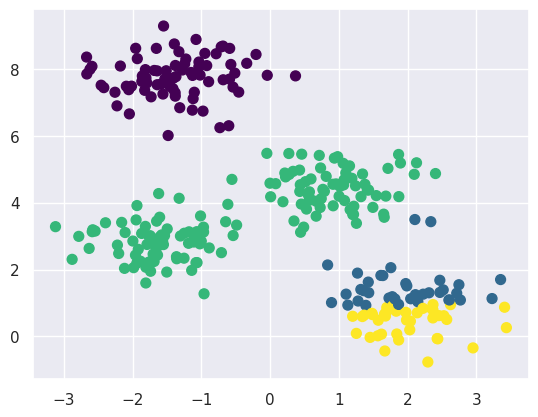

In [14]:
centers, labels = find_clusters(X, 4, rseed=0)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

#### **Optimalisasi Jumlah Klaster**


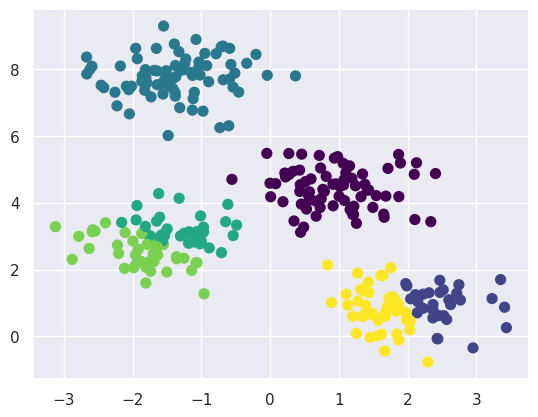

In [15]:
labels = KMeans(6, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

#### **Batas Klaster yang Tidak Selalu Linier**

In [16]:
from sklearn.datasets import make_moons
X, y = make_moons(200, noise=.05, random_state=0)

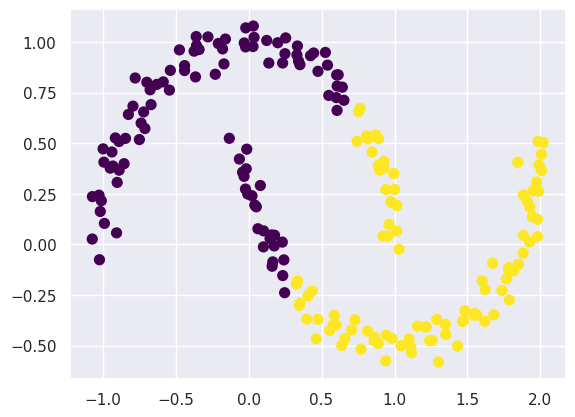

In [17]:
labels = KMeans(2, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


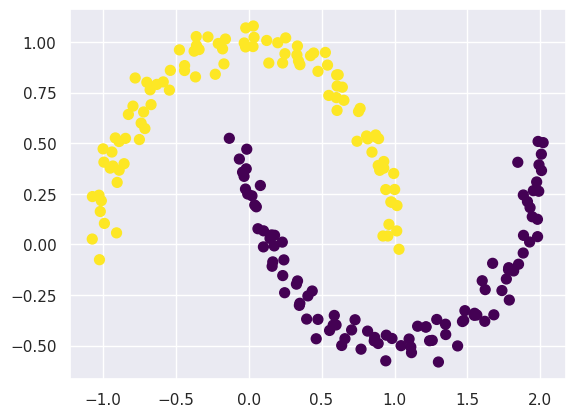

In [18]:
from sklearn.cluster import SpectralClustering
model = SpectralClustering(n_clusters=2, affinity='nearest_neighbors',
                           assign_labels='kmeans')
labels = model.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

### **Contoh Kasus 1: Karakter Angka**

In [19]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.data.shape

(1797, 64)

In [20]:
# terapkan K-Means
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits.data)
kmeans.cluster_centers_.shape

(10, 64)

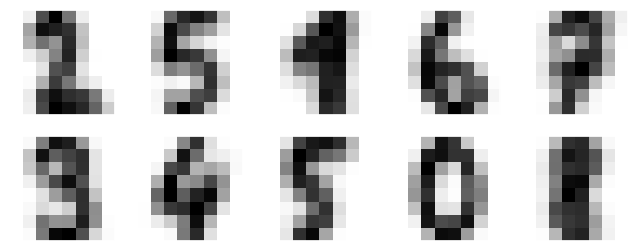

In [21]:
fig, ax = plt.subplots(2, 5, figsize=(8, 3))
centers = kmeans.cluster_centers_.reshape(10, 8, 8)
for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)

In [22]:
from scipy.stats import mode

labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

In [23]:
from sklearn.metrics import accuracy_score
accuracy_score(digits.target, labels)

0.7440178074568725

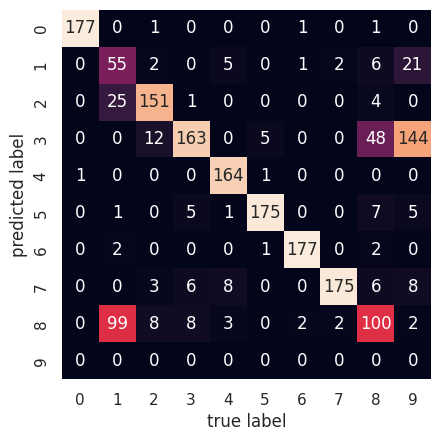

In [24]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(digits.target, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label');

In [25]:
from sklearn.manifold import TSNE


tsne = TSNE(n_components=2, init='random', random_state=0)
digits_proj = tsne.fit_transform(digits.data)

# hitung klaster
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits_proj)

# permutasi label
labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

# hitung akurasi
accuracy_score(digits.target, labels)

0.9410127991096272

### **Studi Kasus 2: Kompresi Citra**

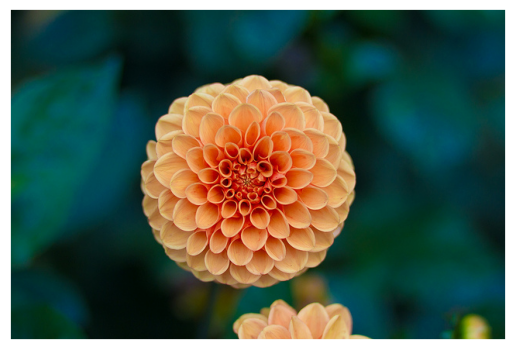

In [26]:
from sklearn.datasets import load_sample_image
flower = load_sample_image("flower.jpg")
ax = plt.axes(xticks=[], yticks=[])
ax.imshow(flower);

In [27]:
flower.shape

(427, 640, 3)

In [28]:
data = flower / 255.0
data = data.reshape(427 * 640, 3)
data.shape

(273280, 3)

In [29]:
def plot_pixels(data, title, colors=None, N=10000):
    if colors is None:
        colors = data

    # choose a random subset
    rng = np.random.RandomState(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    R, G, B = data[i].T

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

    fig.suptitle(title, size=20);

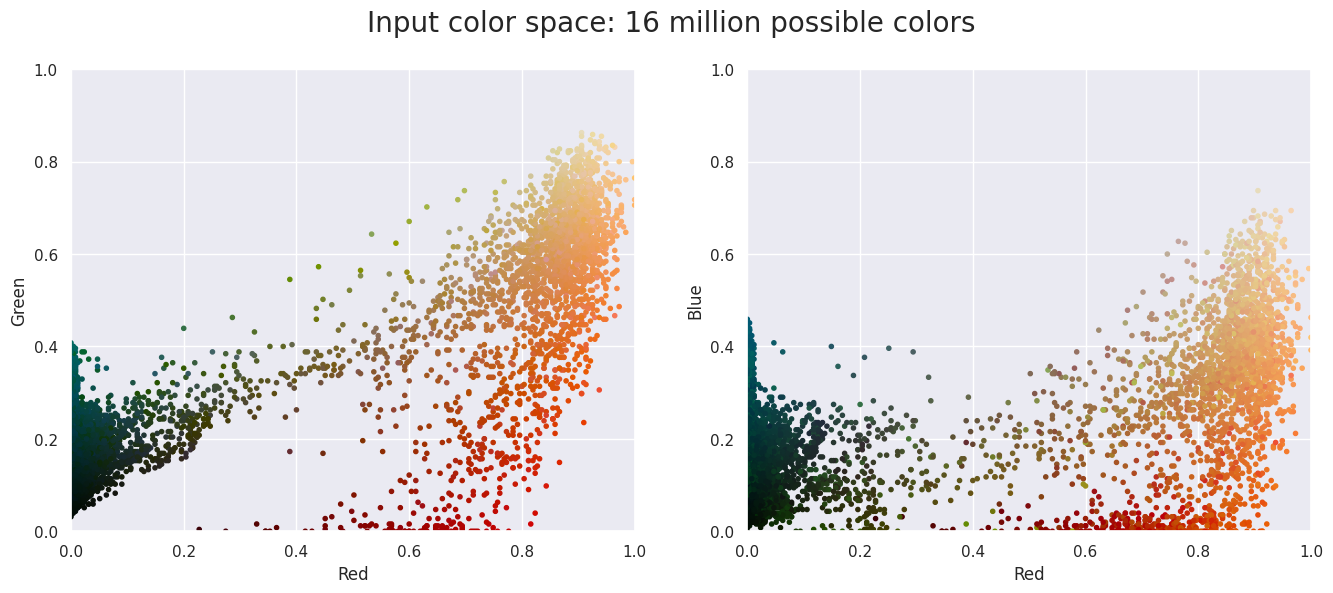

In [30]:
plot_pixels(data, title='Input color space: 16 million possible colors')

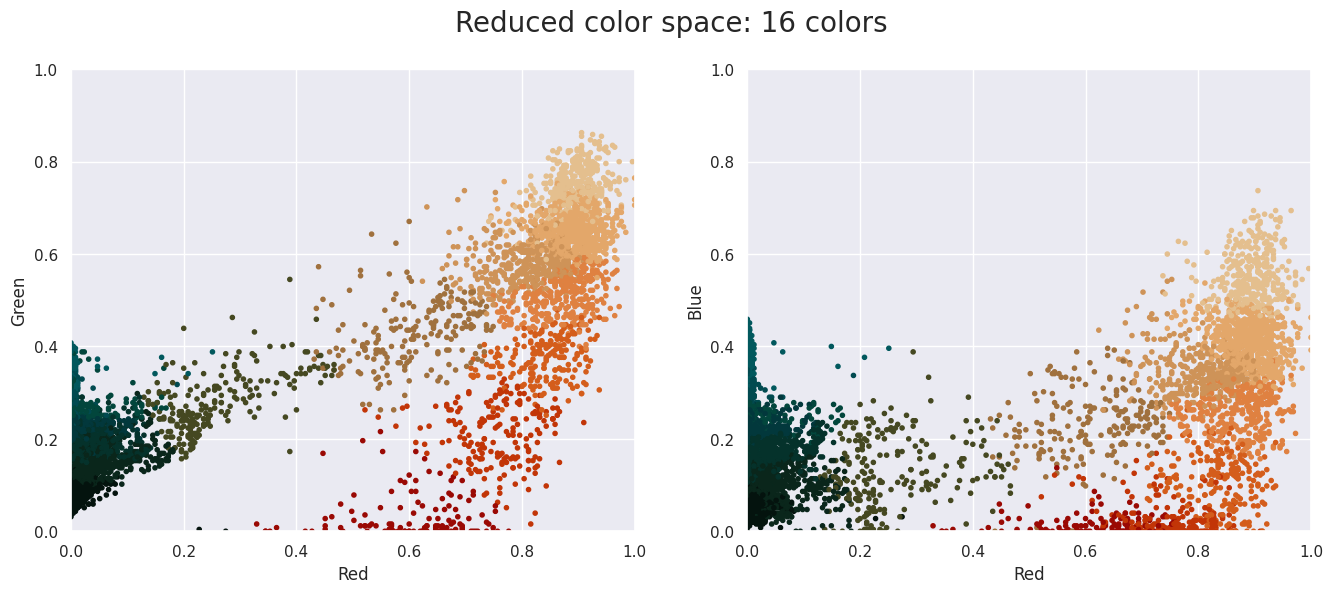

In [31]:
import warnings; warnings.simplefilter('ignore')  # Fix NumPy issues.

from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(16)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

plot_pixels(data, colors=new_colors,title="Reduced color space: 16 colors")

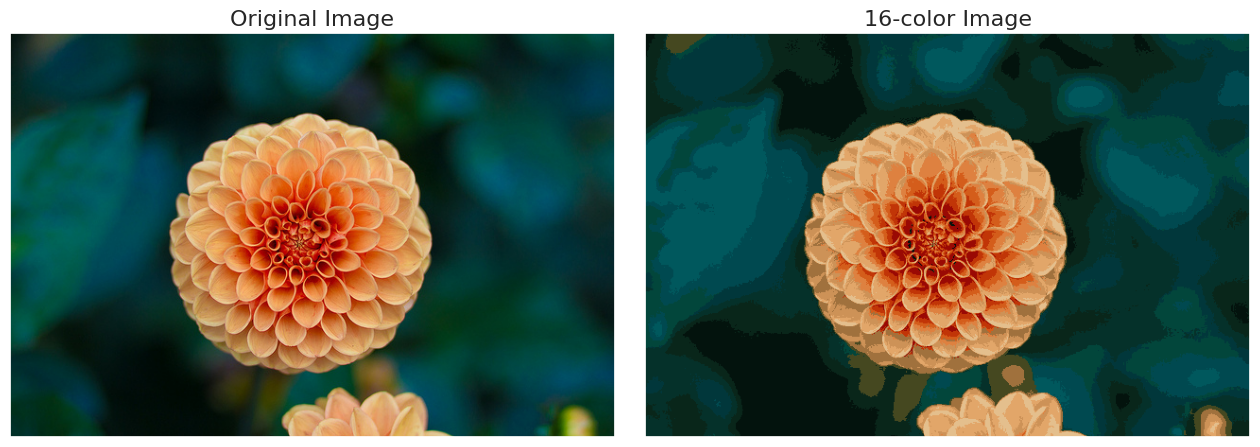

In [32]:
flower_recolored = new_colors.reshape(flower.shape)

fig, ax = plt.subplots(1, 2, figsize=(16, 6),
                       subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(wspace=0.05)
ax[0].imshow(flower)
ax[0].set_title('Original Image', size=16)
ax[1].imshow(flower_recolored)
ax[1].set_title('16-color Image', size=16);

# **Praktikum 3**

**Pembuatan Dataset Sintetis**

Untuk mempelajari DBSCAN, kita akan membuat dataset sederhana berupa 3 klaster buatan menggunakan fungsi  `make_blobs`  dari Scikit-Learn.




In [33]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

centers = [[1, 1], [-1, -1], [1, -1]]
X, labels_true = make_blobs(
    n_samples=750, centers=centers, cluster_std=0.4, random_state=0
)

X = StandardScaler().fit_transform(X)

Visualisasikan data yang dihasilkan dengan cara ini:

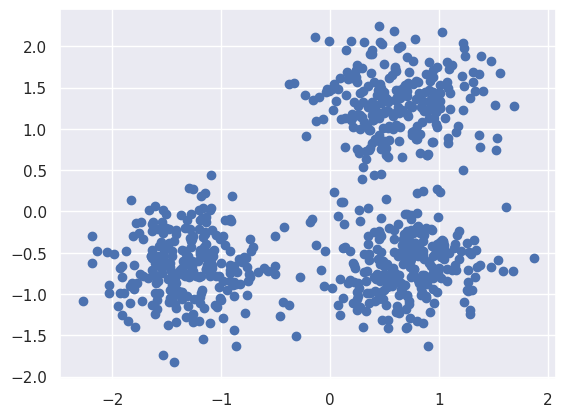

array([[ 0.49426097,  1.45106697],
       [-1.42808099, -0.83706377],
       [ 0.33855918,  1.03875871],
       [ 0.11900101, -1.05397553],
       [ 1.1224246 ,  1.77493654]])

In [34]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1])
plt.show()

X[:5]

#### **Compute DBSCAN**

Sekarang kita terapkan DBSCAN pada data tersebut.

Label yang ditetapkan oleh `DBSCAN` dapat diakses melalui atribut `labels_`. Titik data yang dianggap noise akan diberi label khusus.

In [35]:
import numpy as np

from sklearn import metrics
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.3, min_samples=10).fit(X)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 3
Estimated number of noise points: 18


- `eps=0.3` → jarak maksimum antar titik untuk dianggap tetangga.

- `min_samples=10` → jumlah minimum titik dalam radius `eps` agar dianggap area padat (core sample).

- Label hasil klasterisasi tersedia di labels. Nilai `-1` berarti titik tersebut dianggap **noise** atau **outlier**.

Estimated number of clusters: 3

Estimated number of noise points: 18

#### **Evaluasi Kualitas Klasterisasi**

Karena kita menggunakan dataset sintetis `(make_blobs)`, kita tahu label aslinya `(labels_true)`. Ini memungkinkan kita mengukur kualitas DBSCAN dengan berbagai metrik evaluasi.




In [36]:
print(f"Homogeneity: {metrics.homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(labels_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(labels_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(labels_true, labels):.3f}")
print(
    "Adjusted Mutual Information:"
    f" {metrics.adjusted_mutual_info_score(labels_true, labels):.3f}"
)
print(f"Silhouette Coefficient: {metrics.silhouette_score(X, labels):.3f}")

Homogeneity: 0.953
Completeness: 0.883
V-measure: 0.917
Adjusted Rand Index: 0.952
Adjusted Mutual Information: 0.916
Silhouette Coefficient: 0.626


- **Homogeneity** → apakah tiap klaster hanya berisi satu label asli.

- **Completeness** → apakah semua sampel dengan label asli yang sama masuk ke klaster yang sama.

- **V-measure** → rata-rata harmonik dari homogeneity dan completeness.

- **Adjusted Rand Index (ARI)**→ kesesuaian antara klasterisasi dengan label asli.

- **Adjusted Mutual Information (AMI)**→ kesamaan informasi antara klasterisasi dengan label asli.

- **Silhouette Coefficient**→ seberapa baik data dikelompokkan (nilai mendekati 1 berarti bagus, mendekati 0 berarti berada di batas, negatif berarti salah klaster).

#### **Visualisasi Hasil Klasterisasi**

Kita akan memvisualisasikan hasil DBSCAN.

- **Core sample** ditampilkan dengan titik besar.

- **Non-core sample** ditampilkan dengan titik kecil.

- **Noise** ditampilkan dengan warna hitam.

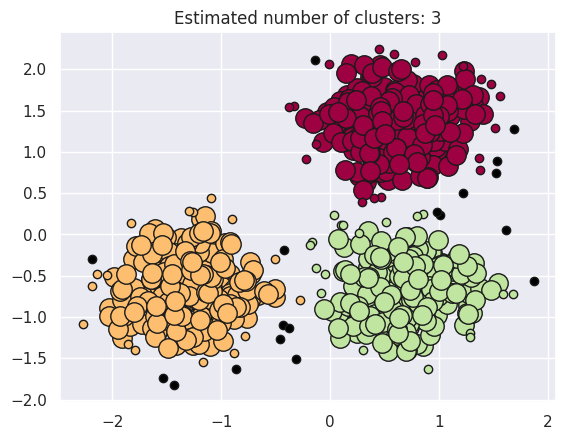

In [37]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

**Interpretasi visual**:

- Titik besar berwarna → **core samples**dalam klaster.

- Titik kecil berwarna → **non-core samples**, tetap termasuk klaster.

- Titik hitam → **noise/outlier**.

# **Tugas Praktikum**

#### **1. Tugas K-Means**

Download Dataset Berikut

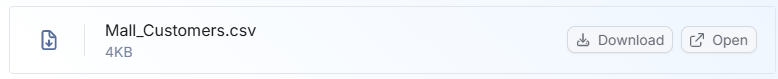

Buatlah sebuah model K-Means dengan ketentuan,

1. Gunakan data 'Mall_Customers.csv'
2. Tentukan fitur apa yang tepat untuk melakukan clustering (minimal 2)
3. Buatlah model K-Means dengan mempertimbangkan jumlah k yang terbaik.

##### **Langkah 1: Import Library dan Load Dataset**

Download file Mall_Customers.csv dari link di modul, lalu kita upload ke Colab (drag file ke panel).

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


##### **Langkah 2 Cek kolom**



In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


##### **Langkah 3 Seleksi Fitur Clustering**

Fitur yang dipilih adalah `Annual Income (k$)` dan `Spending Score (1-100)` karena
keduanya bersifat numerik dan relevan untuk menggambarkan pola belanja pelanggan.

In [40]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


##### **Langkah 4 Visualisasi Data Awal**

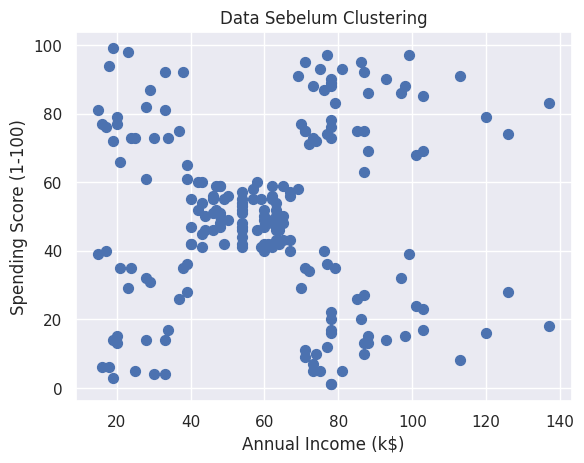

In [41]:
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s=50)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Data Sebelum Clustering')
plt.show()

##### **Langkah 5 Menentukan Jumlah k Terbaik (Metode Elbow)**

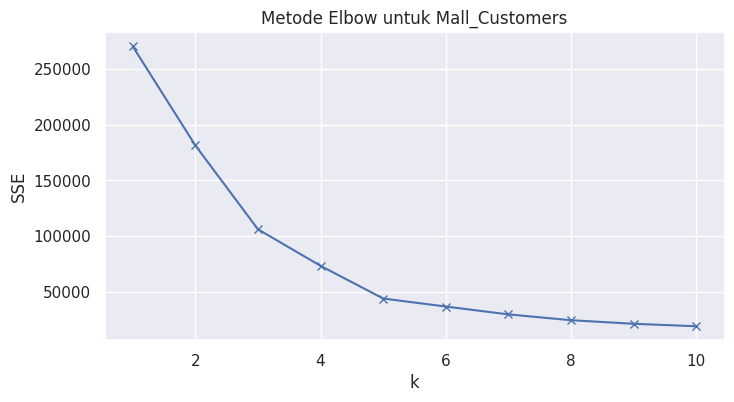

k=1; SSE=269981.28
k=2; SSE=181363.60
k=3; SSE=106348.37
k=4; SSE=73679.79
k=5; SSE=44448.46
k=6; SSE=37265.87
k=7; SSE=30259.66
k=8; SSE=25050.83
k=9; SSE=21862.09
k=10; SSE=19657.78


In [42]:
sse = []
K = range(1, 11)

for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeanModel.fit(X)
    sse.append(kmeanModel.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, sse, "bx-")
plt.xlabel("k")
plt.ylabel("SSE")
plt.title("Metode Elbow untuk Mall_Customers")
plt.show()

for idx, sse_val in enumerate(sse, start=1):
    print(f'k={idx}; SSE={sse_val:.2f}')

##### **Langkah 6 Analisis Elbow**

Berdasarkan grafik elbow, titik "siku" terlihat pada k=5, sehingga jumlah klaster
yang dipilih adalah 5.

In [51]:
k_terbaik = 5

kmeans_final = KMeans(n_clusters=k_terbaik, random_state=0, n_init=10)
y_kmeans = kmeans_final.fit_predict(X)

##### **Langkah 7 Visualisasi Hasil Clustering**

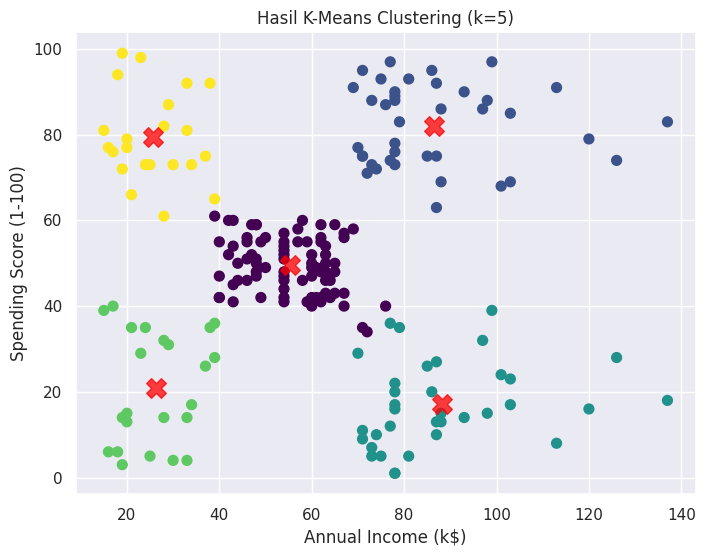

Nilai SSE final: 44448.46


In [44]:
plt.figure(figsize=(8, 6))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans_final.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X')

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title(f'Hasil K-Means Clustering (k={k_terbaik})')
plt.show()

print(f'Nilai SSE final: {kmeans_final.inertia_:.2f}')

#### **2. Tugas DBSCAN**


1. Buat dataset make_moons (1000 sampel, noise=0.05), lalu normalisasi.
2. Jalankan DBSCAN dengan `eps=0.2`, `min_samples=5`, hitung jumlah klaster & noise.
3. Evaluasi dengan metrik: Homogeneity, Completeness, V-measure, ARI, AMI, Silhouette.
4. Visualisasikan hasil DBSCAN (core sample = titik besar, non-core = titik kecil, noise = hitam).
5. Lakukan eksperimen:
    - `eps = 0.05, 0.1, 0.3, 0.5`
    - `min_samples = 3, 10, 20`
    - Catat perubahan klaster, noise, dan kualitas evaluasi.

##### **Langkah 1 Buat dataset & normalisasi**

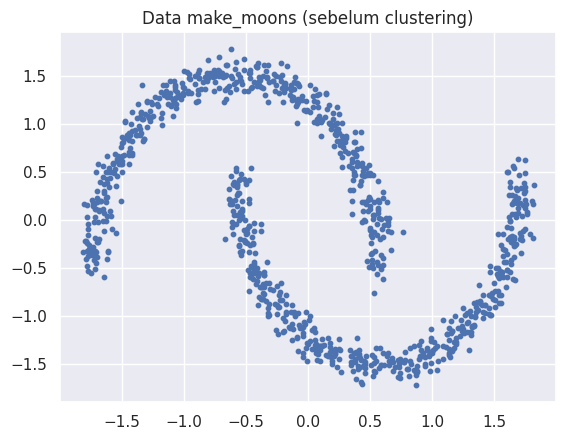

In [45]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn import metrics

X_moons, labels_true = make_moons(n_samples=1000, noise=0.05, random_state=0)
X_moons = StandardScaler().fit_transform(X_moons)

plt.scatter(X_moons[:, 0], X_moons[:, 1], s=10)
plt.title('Data make_moons (sebelum clustering)')
plt.show()

##### **Langkah 2 Jalankan DBSCAN (eps=0.2, min_samples=5)**

In [46]:
db = DBSCAN(eps=0.2, min_samples=5).fit(X_moons)
labels = db.labels_

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print(f"Estimated number of clusters: {n_clusters_}")
print(f"Estimated number of noise points: {n_noise_}")

Estimated number of clusters: 2
Estimated number of noise points: 0


##### **Langkah 3 Evaluasi metrik**

In [47]:
print(f"Homogeneity: {metrics.homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(labels_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(labels_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(labels_true, labels):.3f}")
print(f"Adjusted Mutual Information: {metrics.adjusted_mutual_info_score(labels_true, labels):.3f}")
print(f"Silhouette Coefficient: {metrics.silhouette_score(X_moons, labels):.3f}")

Homogeneity: 1.000
Completeness: 1.000
V-measure: 1.000
Adjusted Rand Index: 1.000
Adjusted Mutual Information: 1.000
Silhouette Coefficient: 0.392


##### **Langkah 4 Visualisasi hasil DBSCAN**

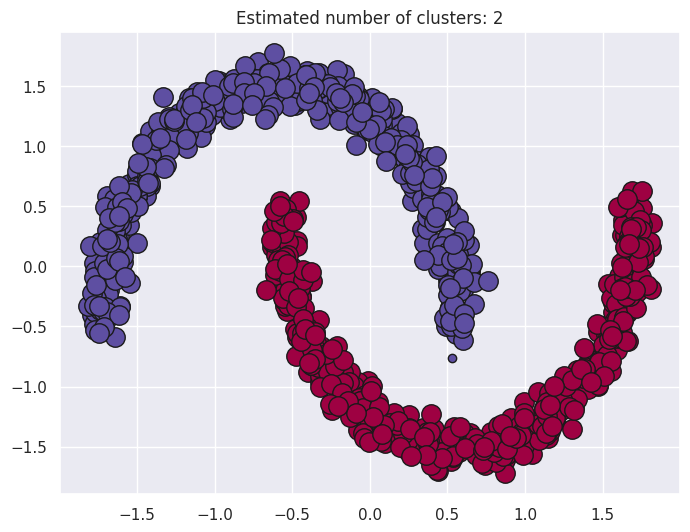

In [48]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

plt.figure(figsize=(8, 6))
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]  # noise = hitam

    class_member_mask = labels == k

    xy = X_moons[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], "o", markerfacecolor=tuple(col),
              markeredgecolor="k", markersize=14)

    xy = X_moons[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], "o", markerfacecolor=tuple(col),
              markeredgecolor="k", markersize=6)

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

##### **Langkah 5 Eksperimen eps & min_samples**

In [49]:
def run_dbscan(X, y_true, eps, min_samples):
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
    labels = db.labels_

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    print(f"eps={eps}, min_samples={min_samples}")
    print(f"  Jumlah cluster : {n_clusters}")
    print(f"  Jumlah noise   : {n_noise}")

    if n_clusters > 1:
        print(f"  Homogeneity    : {metrics.homogeneity_score(y_true, labels):.3f}")
        print(f"  Completeness   : {metrics.completeness_score(y_true, labels):.3f}")
        print(f"  V-measure      : {metrics.v_measure_score(y_true, labels):.3f}")
        print(f"  ARI            : {metrics.adjusted_rand_score(y_true, labels):.3f}")
        print(f"  AMI            : {metrics.adjusted_mutual_info_score(y_true, labels):.3f}")
        print(f"  Silhouette     : {metrics.silhouette_score(X, labels):.3f}")
    else:
        print("  (Metrik evaluasi tidak dihitung karena cluster < 2)")

    plt.figure(figsize=(5, 4))
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=15)
    plt.title(f"eps={eps}, min_samples={min_samples} -> {n_clusters} cluster, {n_noise} noise")
    plt.show()
    print("-" * 50)

untuk semua kombinas, sebagai berikut:

eps=0.05, min_samples=3
  Jumlah cluster : 67
  Jumlah noise   : 197
  Homogeneity    : 0.804
  Completeness   : 0.155
  V-measure      : 0.260
  ARI            : 0.033
  AMI            : 0.246
  Silhouette     : 0.078


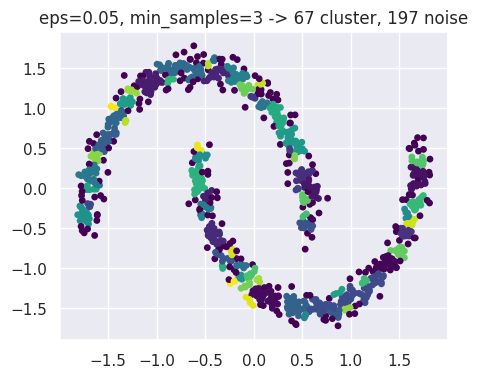

--------------------------------------------------
eps=0.05, min_samples=10
  Jumlah cluster : 0
  Jumlah noise   : 1000
  (Metrik evaluasi tidak dihitung karena cluster < 2)


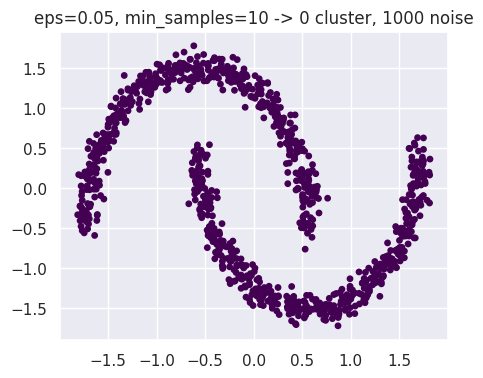

--------------------------------------------------
eps=0.05, min_samples=20
  Jumlah cluster : 0
  Jumlah noise   : 1000
  (Metrik evaluasi tidak dihitung karena cluster < 2)


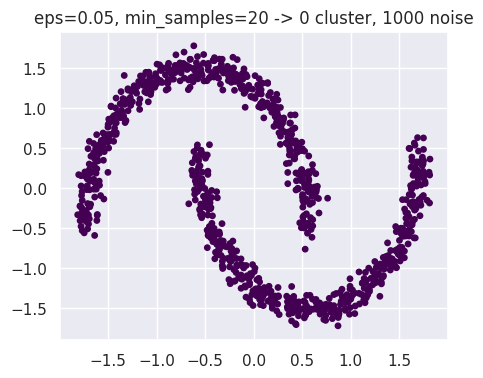

--------------------------------------------------
eps=0.1, min_samples=3
  Jumlah cluster : 3
  Jumlah noise   : 18
  Homogeneity    : 0.983
  Completeness   : 0.708
  V-measure      : 0.824
  ARI            : 0.854
  AMI            : 0.823
  Silhouette     : 0.138


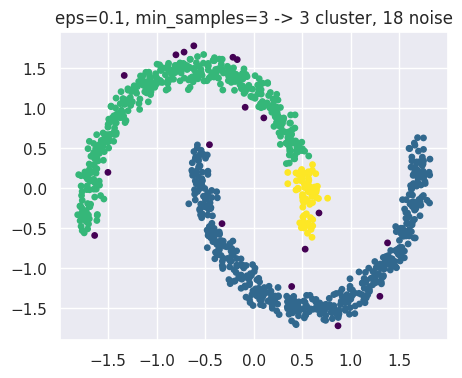

--------------------------------------------------
eps=0.1, min_samples=10
  Jumlah cluster : 9
  Jumlah noise   : 63
  Homogeneity    : 0.939
  Completeness   : 0.358
  V-measure      : 0.519
  ARI            : 0.435
  AMI            : 0.517
  Silhouette     : 0.184


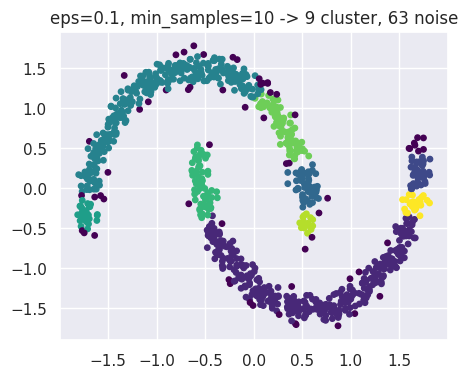

--------------------------------------------------
eps=0.1, min_samples=20
  Jumlah cluster : 6
  Jumlah noise   : 844
  Homogeneity    : 0.157
  Completeness   : 0.153
  V-measure      : 0.155
  ARI            : 0.010
  AMI            : 0.152
  Silhouette     : -0.409


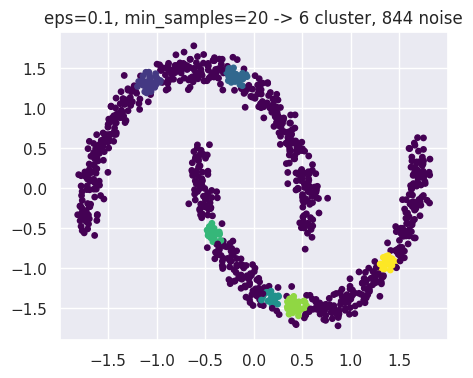

--------------------------------------------------
eps=0.3, min_samples=3
  Jumlah cluster : 2
  Jumlah noise   : 0
  Homogeneity    : 1.000
  Completeness   : 1.000
  V-measure      : 1.000
  ARI            : 1.000
  AMI            : 1.000
  Silhouette     : 0.392


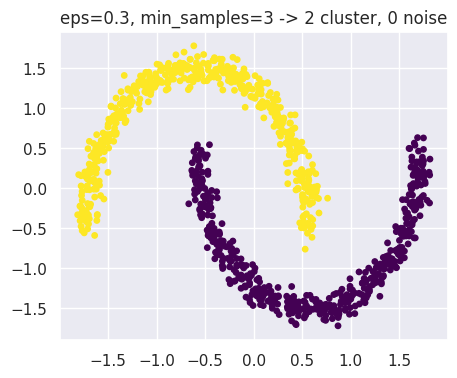

--------------------------------------------------
eps=0.3, min_samples=10
  Jumlah cluster : 2
  Jumlah noise   : 0
  Homogeneity    : 1.000
  Completeness   : 1.000
  V-measure      : 1.000
  ARI            : 1.000
  AMI            : 1.000
  Silhouette     : 0.392


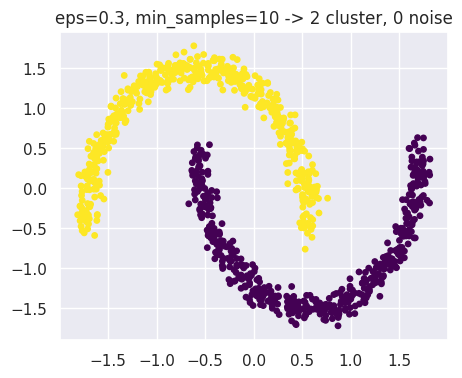

--------------------------------------------------
eps=0.3, min_samples=20
  Jumlah cluster : 2
  Jumlah noise   : 0
  Homogeneity    : 1.000
  Completeness   : 1.000
  V-measure      : 1.000
  ARI            : 1.000
  AMI            : 1.000
  Silhouette     : 0.392


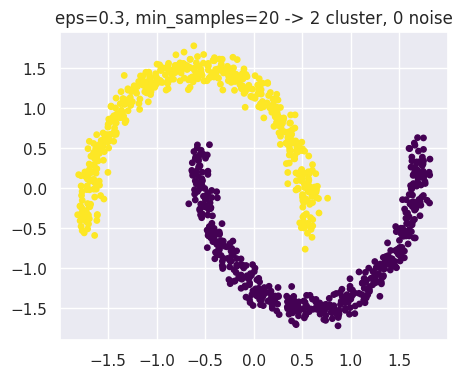

--------------------------------------------------
eps=0.5, min_samples=3
  Jumlah cluster : 1
  Jumlah noise   : 0
  (Metrik evaluasi tidak dihitung karena cluster < 2)


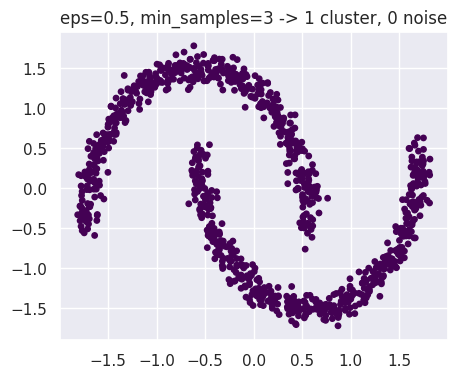

--------------------------------------------------
eps=0.5, min_samples=10
  Jumlah cluster : 1
  Jumlah noise   : 0
  (Metrik evaluasi tidak dihitung karena cluster < 2)


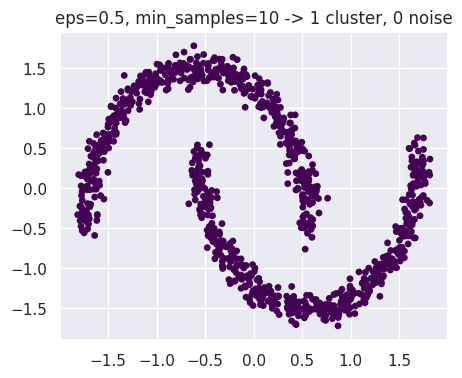

--------------------------------------------------
eps=0.5, min_samples=20
  Jumlah cluster : 2
  Jumlah noise   : 0
  Homogeneity    : 0.990
  Completeness   : 0.990
  V-measure      : 0.990
  ARI            : 0.996
  AMI            : 0.990
  Silhouette     : 0.393


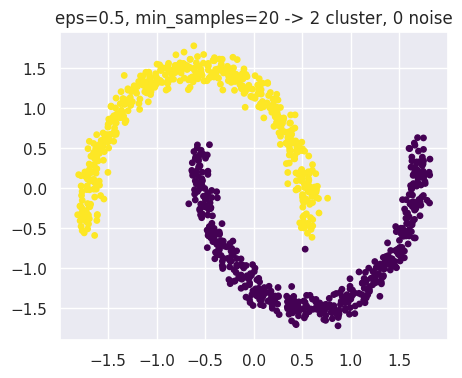

--------------------------------------------------


In [50]:
eps_list = [0.05, 0.1, 0.3, 0.5]
min_samples_list = [3, 10, 20]

for eps in eps_list:
    for min_samples in min_samples_list:
        run_dbscan(X_moons, labels_true, eps, min_samples)

###### hasil dari 12 kombinasi (`eps` × `min_samples`)

In [52]:
import pandas as pd

hasil = []

for eps in eps_list:
    for min_samples in min_samples_list:
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_moons)
        labels = db.labels_
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        if n_clusters > 1:
            sil = metrics.silhouette_score(X_moons, labels)
            ari = metrics.adjusted_rand_score(labels_true, labels)
        else:
            sil = None
            ari = None

        hasil.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'ARI': ari,
            'Silhouette': sil
        })

df_hasil = pd.DataFrame(hasil)
df_hasil

,eps,min_samples,n_clusters,n_noise,ARI,Silhouette
0,0.05,3,67,197,0.032984,0.077967
1,0.05,10,0,1000,NaN,NaN
2,0.05,20,0,1000,NaN,NaN
3,0.10,3,3,18,0.854285,0.137887
4,0.10,10,9,63,0.435052,0.184140
5,0.10,20,6,844,0.010402,-0.409118
6,0.30,3,2,0,1.000000,0.391597
7,0.30,10,2,0,1.000000,0.391597
8,0.30,20,2,0,1.000000,0.391597
9,0.50,3,1,0,NaN,NaN


**Kesimpulan**:

Nilai eps dan min_samples sangat memengaruhi hasil klasterisasi DBSCAN. Semakin besar eps, klaster cenderung menyatu dan jumlahnya berkurang; semakin kecil eps, data lebih rentan dianggap noise. Sementara itu, min_samples yang besar memperketat syarat core point sehingga cenderung menambah noise atau mengurangi jumlah klaster. Kombinasi parameter yang tepat menghasilkan klaster sesuai bentuk asli data dengan nilai evaluasi (Silhouette dan ARI) yang tinggi.